In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils


In [9]:
# CIFAR-10 data preprocessing
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

# Load CIFAR-10 dataset
dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

num_classes = 10
image_shape = (3, 32, 32)


Files already downloaded and verified


In [10]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_shape):
        super(ConditionalGenerator, self).__init__()
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        self.img_shape = img_shape
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_embedding(labels)
        gen_input = torch.cat((noise, label_input), -1)
        img = self.model(gen_input)
        return img.view(img.size(0), *self.img_shape)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes, img_shape):
        super(ConditionalDiscriminator, self).__init__()
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)) + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_input = self.label_embedding(labels)
        flat_img = img.view(img.size(0), -1)
        d_input = torch.cat((flat_img, label_input), -1)
        return self.model(d_input)


In [11]:
latent_dim = 20
generator = ConditionalGenerator(latent_dim, num_classes, image_shape)
discriminator = ConditionalDiscriminator(num_classes, image_shape)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
adversarial_loss.to(device)


BCELoss()

Starting Training Loop...
[Epoch 1/100] Loss_D: 0.442892849445343 Loss_G: 1.9050743579864502
[Epoch 2/100] Loss_D: 0.6813141703605652 Loss_G: 1.4498043060302734
[Epoch 3/100] Loss_D: 0.4826655685901642 Loss_G: 1.5593701601028442
[Epoch 4/100] Loss_D: 0.719218373298645 Loss_G: 1.289300799369812
[Epoch 5/100] Loss_D: 0.5796914100646973 Loss_G: 1.3148003816604614
[Epoch 6/100] Loss_D: 0.5018681287765503 Loss_G: 1.4506564140319824
[Epoch 7/100] Loss_D: 0.5034409761428833 Loss_G: 1.2578098773956299
[Epoch 8/100] Loss_D: 0.5337378978729248 Loss_G: 1.396121621131897
[Epoch 9/100] Loss_D: 0.5856391191482544 Loss_G: 1.0583289861679077
[Epoch 10/100] Loss_D: 0.536872148513794 Loss_G: 1.3326125144958496


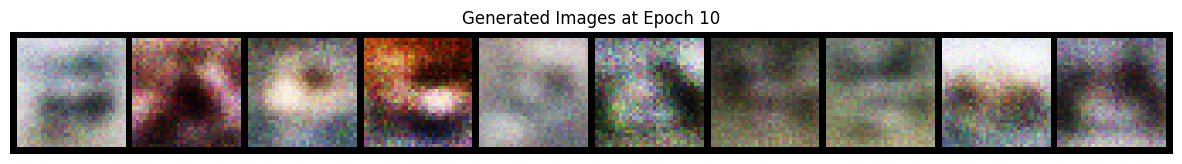

[Epoch 11/100] Loss_D: 0.5247906446456909 Loss_G: 1.2521766424179077
[Epoch 12/100] Loss_D: 0.6087398529052734 Loss_G: 1.0463132858276367
[Epoch 13/100] Loss_D: 0.6831732988357544 Loss_G: 1.2604382038116455
[Epoch 14/100] Loss_D: 0.6635009050369263 Loss_G: 1.0310683250427246
[Epoch 15/100] Loss_D: 0.6511712670326233 Loss_G: 1.2052414417266846
[Epoch 16/100] Loss_D: 0.6028308868408203 Loss_G: 1.147216558456421
[Epoch 17/100] Loss_D: 0.6809517741203308 Loss_G: 1.1301876306533813
[Epoch 18/100] Loss_D: 0.5945011377334595 Loss_G: 1.0787168741226196
[Epoch 19/100] Loss_D: 0.6793419122695923 Loss_G: 1.065156102180481
[Epoch 20/100] Loss_D: 0.5906767845153809 Loss_G: 1.052993893623352


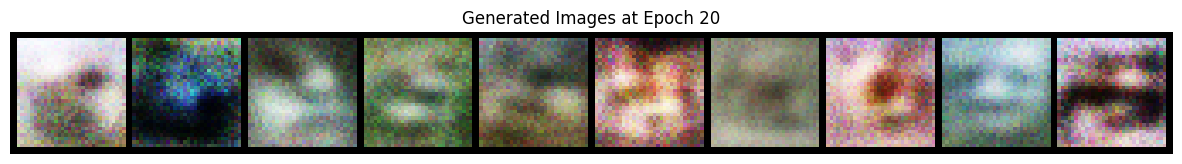

[Epoch 21/100] Loss_D: 0.6198392510414124 Loss_G: 1.1285297870635986
[Epoch 22/100] Loss_D: 0.5955572128295898 Loss_G: 1.053666353225708
[Epoch 23/100] Loss_D: 0.6650055646896362 Loss_G: 1.1414974927902222
[Epoch 24/100] Loss_D: 0.6361804008483887 Loss_G: 1.0815484523773193
[Epoch 25/100] Loss_D: 0.618659257888794 Loss_G: 1.1138476133346558
[Epoch 26/100] Loss_D: 0.6704549193382263 Loss_G: 0.9340197443962097
[Epoch 27/100] Loss_D: 0.6476064920425415 Loss_G: 1.020037055015564
[Epoch 28/100] Loss_D: 0.6216068267822266 Loss_G: 1.0512028932571411
[Epoch 29/100] Loss_D: 0.6132195591926575 Loss_G: 1.0798251628875732
[Epoch 30/100] Loss_D: 0.5777961015701294 Loss_G: 1.0889432430267334


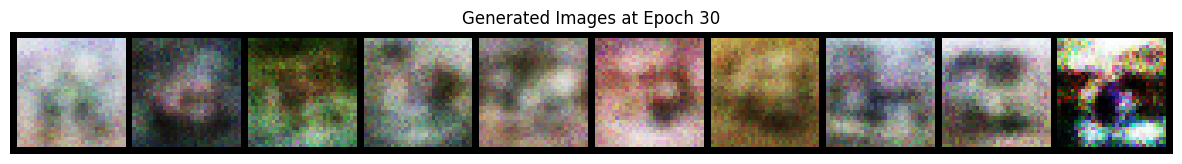

[Epoch 31/100] Loss_D: 0.6844065189361572 Loss_G: 0.9770315289497375
[Epoch 32/100] Loss_D: 0.6411395072937012 Loss_G: 0.913638710975647
[Epoch 33/100] Loss_D: 0.6339670419692993 Loss_G: 0.9333184361457825
[Epoch 34/100] Loss_D: 0.6658128499984741 Loss_G: 0.9025567770004272
[Epoch 35/100] Loss_D: 0.6755030155181885 Loss_G: 0.9503731727600098
[Epoch 36/100] Loss_D: 0.6399654150009155 Loss_G: 0.9366075396537781
[Epoch 37/100] Loss_D: 0.6808212995529175 Loss_G: 0.923331081867218
[Epoch 38/100] Loss_D: 0.6506870985031128 Loss_G: 0.8988401293754578
[Epoch 39/100] Loss_D: 0.6090430021286011 Loss_G: 0.9713783264160156
[Epoch 40/100] Loss_D: 0.6383359432220459 Loss_G: 0.9958696365356445


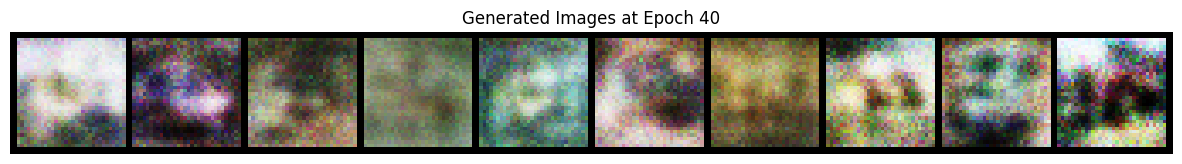

[Epoch 41/100] Loss_D: 0.6652275323867798 Loss_G: 0.8960069417953491
[Epoch 42/100] Loss_D: 0.6449809074401855 Loss_G: 0.9278382062911987
[Epoch 43/100] Loss_D: 0.6859807372093201 Loss_G: 0.8910072445869446
[Epoch 44/100] Loss_D: 0.6957423686981201 Loss_G: 0.9549892544746399
[Epoch 45/100] Loss_D: 0.6339496374130249 Loss_G: 0.9102286100387573
[Epoch 46/100] Loss_D: 0.6678988933563232 Loss_G: 0.9291659593582153
[Epoch 47/100] Loss_D: 0.6627820730209351 Loss_G: 0.8934817314147949
[Epoch 48/100] Loss_D: 0.682439923286438 Loss_G: 0.80390864610672
[Epoch 49/100] Loss_D: 0.6746790409088135 Loss_G: 0.8773180842399597
[Epoch 50/100] Loss_D: 0.6485275626182556 Loss_G: 0.8906604051589966


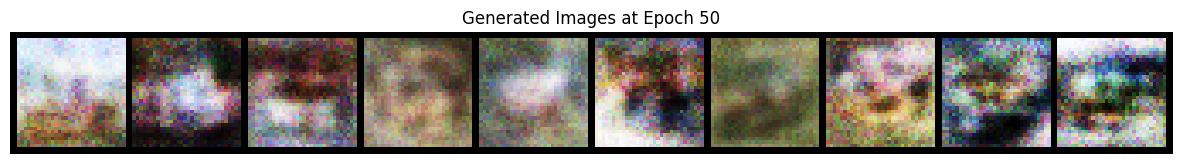

[Epoch 51/100] Loss_D: 0.6475050449371338 Loss_G: 0.9222512245178223
[Epoch 52/100] Loss_D: 0.696427583694458 Loss_G: 0.8898141980171204
[Epoch 53/100] Loss_D: 0.673892617225647 Loss_G: 0.860992431640625
[Epoch 54/100] Loss_D: 0.6772806644439697 Loss_G: 0.8184362649917603
[Epoch 55/100] Loss_D: 0.7114537954330444 Loss_G: 0.8322402834892273
[Epoch 56/100] Loss_D: 0.6754738092422485 Loss_G: 0.9106435775756836
[Epoch 57/100] Loss_D: 0.6683578491210938 Loss_G: 0.8436837196350098
[Epoch 58/100] Loss_D: 0.6611302495002747 Loss_G: 0.8541101217269897
[Epoch 59/100] Loss_D: 0.6616827249526978 Loss_G: 0.8510500192642212
[Epoch 60/100] Loss_D: 0.6380008459091187 Loss_G: 0.8555032014846802


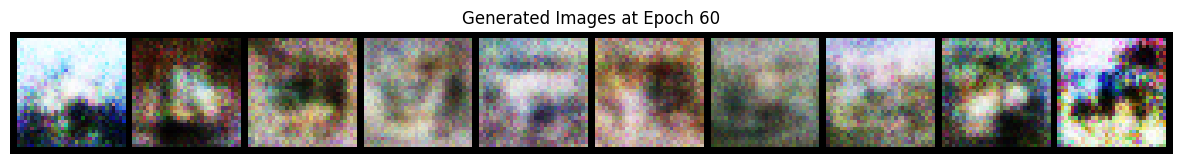

[Epoch 61/100] Loss_D: 0.6879135966300964 Loss_G: 0.8171107172966003
[Epoch 62/100] Loss_D: 0.6684744358062744 Loss_G: 0.9054150581359863
[Epoch 63/100] Loss_D: 0.6385568380355835 Loss_G: 0.877379298210144
[Epoch 64/100] Loss_D: 0.7024003267288208 Loss_G: 0.7750498056411743
[Epoch 65/100] Loss_D: 0.6978247165679932 Loss_G: 0.8383620381355286
[Epoch 66/100] Loss_D: 0.6821852922439575 Loss_G: 0.843682587146759
[Epoch 67/100] Loss_D: 0.6946694254875183 Loss_G: 0.8793269991874695
[Epoch 68/100] Loss_D: 0.6379077434539795 Loss_G: 0.9099308848381042
[Epoch 69/100] Loss_D: 0.6794806718826294 Loss_G: 0.8014875650405884
[Epoch 70/100] Loss_D: 0.6430493593215942 Loss_G: 0.8761944770812988


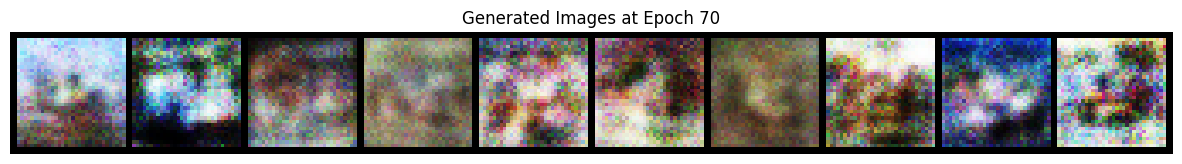

[Epoch 71/100] Loss_D: 0.6651452779769897 Loss_G: 0.886146068572998
[Epoch 72/100] Loss_D: 0.6689417958259583 Loss_G: 0.8207486867904663
[Epoch 73/100] Loss_D: 0.6726557016372681 Loss_G: 0.8481111526489258
[Epoch 74/100] Loss_D: 0.6716861724853516 Loss_G: 0.7840002775192261
[Epoch 75/100] Loss_D: 0.6372304558753967 Loss_G: 0.8576100468635559
[Epoch 76/100] Loss_D: 0.6843376755714417 Loss_G: 0.8723751902580261
[Epoch 77/100] Loss_D: 0.6889635324478149 Loss_G: 0.7947946786880493
[Epoch 78/100] Loss_D: 0.6870291233062744 Loss_G: 0.8117653131484985
[Epoch 79/100] Loss_D: 0.6806603670120239 Loss_G: 0.844532310962677
[Epoch 80/100] Loss_D: 0.6874452829360962 Loss_G: 0.8728510141372681


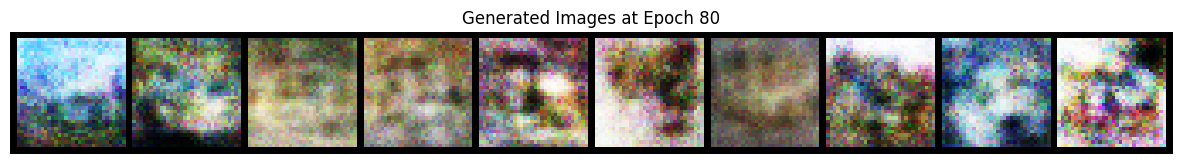

[Epoch 81/100] Loss_D: 0.6762833595275879 Loss_G: 0.836966335773468
[Epoch 82/100] Loss_D: 0.6655017137527466 Loss_G: 0.8188266754150391
[Epoch 83/100] Loss_D: 0.6740337014198303 Loss_G: 0.8100374937057495
[Epoch 84/100] Loss_D: 0.6876356601715088 Loss_G: 0.8535860180854797
[Epoch 85/100] Loss_D: 0.6781109571456909 Loss_G: 0.7681294679641724
[Epoch 86/100] Loss_D: 0.6904269456863403 Loss_G: 0.8250223398208618
[Epoch 87/100] Loss_D: 0.6770317554473877 Loss_G: 0.8115811347961426
[Epoch 88/100] Loss_D: 0.7028250694274902 Loss_G: 0.8044091463088989
[Epoch 89/100] Loss_D: 0.6880127191543579 Loss_G: 0.827523410320282
[Epoch 90/100] Loss_D: 0.6957999467849731 Loss_G: 0.8283249139785767


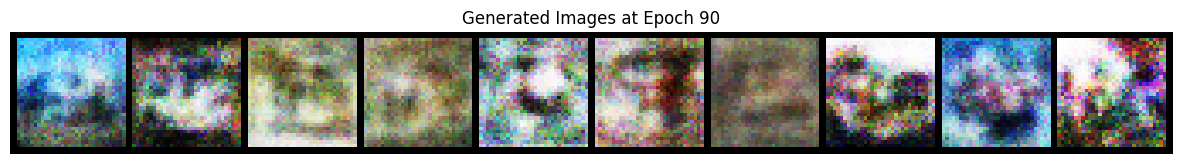

[Epoch 91/100] Loss_D: 0.6316174268722534 Loss_G: 0.8526903986930847
[Epoch 92/100] Loss_D: 0.6687761545181274 Loss_G: 0.7929215431213379
[Epoch 93/100] Loss_D: 0.6957671642303467 Loss_G: 0.7933123707771301
[Epoch 94/100] Loss_D: 0.6887630224227905 Loss_G: 0.7731670141220093
[Epoch 95/100] Loss_D: 0.6604427099227905 Loss_G: 0.7912622690200806
[Epoch 96/100] Loss_D: 0.7195948362350464 Loss_G: 0.7606610059738159
[Epoch 97/100] Loss_D: 0.7110399007797241 Loss_G: 0.7665682435035706
[Epoch 98/100] Loss_D: 0.6868126392364502 Loss_G: 0.8409335017204285
[Epoch 99/100] Loss_D: 0.684345006942749 Loss_G: 0.8305980563163757
[Epoch 100/100] Loss_D: 0.6692384481430054 Loss_G: 0.79930180311203


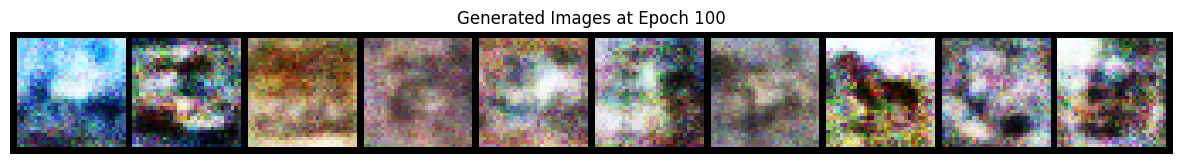

In [12]:
# Fixed noise for consistent visualization
fixed_noise = torch.randn(10, latent_dim, device=device)
fixed_labels = torch.tensor([i for i in range(num_classes)], device=device)

G_losses = []
D_losses = []
print("Starting Training Loop...")

epochs = 100
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(dataloader):

        # Move data to device
        imgs, labels = imgs.to(device), labels.to(device)

        # Real labels = 1, Fake labels = 0
        real = torch.ones((imgs.size(0), 1), device=device)
        fake = torch.zeros((imgs.size(0), 1), device=device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        discriminator.zero_grad()

        # Loss for real images
        real_loss = adversarial_loss(discriminator(imgs, labels), real)

        # Generate fake images
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z, labels)

        # Loss for fake images
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), labels), fake)

        # Total discriminator loss
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        generator.zero_grad()

        # Labels are real for generator loss
        g_loss = adversarial_loss(discriminator(gen_imgs, labels), real)
        g_loss.backward()
        optimizer_G.step()

        # Track losses
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())

    # Display progress and generate samples
    print(f"[Epoch {epoch+1}/{epochs}] Loss_D: {d_loss.item()} Loss_G: {g_loss.item()}")

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            gen_imgs = generator(fixed_noise, fixed_labels).detach().cpu()
        grid = vutils.make_grid(gen_imgs, nrow=10, normalize=True)
        plt.figure(figsize=(15, 5))
        plt.axis("off")
        plt.title(f"Generated Images at Epoch {epoch+1}")
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.show()
